
# Airport Network Dynamics — Simple Epidemic Propagation

This notebook adds a **simple dynamical process** on top of the airport network from Assignment 3.

We simulate a basic **SIR epidemic model** on the USA airport network:

- **S** = Susceptible airports
- **I** = Infected airports
- **R** = Recovered airports

Interpretation for airport networks:
- An infected airport represents an airport currently spreading disruption/delay/virus.
- Infection propagates through flight connections.
- Recovery means the airport is no longer spreading.

This is intentionally simple and explainable so it can later be extended into:
- weighted spreading,
- traffic-based transmission,
- cascading failures,
- targeted attacks,
- temporal dynamics,
- multilayer networks.


In [16]:

from pathlib import Path
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from utils import AirportDatasetConfig, run_pipeline

from bokeh.io import output_notebook, show
from bokeh.models import (
    Circle,
    MultiLine,
    HoverTool,
    ColumnDataSource
)
from bokeh.plotting import figure
from bokeh.plotting import from_networkx
from bokeh.palettes import Spectral4

output_notebook()

plt.rcParams['figure.figsize'] = (10, 5)


Loading BokehJS ...


## Load the airport network

This reuses the exact same paths and variable names from the original assignment notebook.


In [3]:

# Same configuration as the original notebook
DATA_ROOT = Path('../data')

config = AirportDatasetConfig(
    nodes_path=str(DATA_ROOT / 'reachability-meta.csv' / 'reachability-meta.csv'),
    edges_path=str(DATA_ROOT / 'reachability.txt' / 'reachability.txt'),
    node_id_col='node_id',
    node_name_col='name',
    node_lat_col='latitude',
    node_lon_col='longitude',
    node_pop_col='metro_pop',
    edge_source_col='FromNodeId',
    edge_target_col='ToNodeId',
    edge_weight_col='Weight',
)

result = run_pipeline(config)

G = result['G']
G_undirected = result['G_undirected']

# print(nx.info(G_undirected))



## Simple SIR simulation

At each timestep:

1. Every infected airport can infect its neighbors with probability `beta`
2. Every infected airport recovers with probability `gamma`

This is one of the most classical spreading models in complex networks.


# SIR Dynamical Model on the Airport Network

To model the propagation process on the USA airport network, we use a discrete-time SIR (Susceptible–Infected–Recovered) model.

Each airport belongs to one of three possible states:

- **Susceptible (S):** the airport is not yet affected,
- **Infected (I):** the airport can transmit the process to neighboring airports,
- **Recovered (R):** the airport no longer propagates the process.

At every timestep:

- an infected airport infects each neighboring airport with probability $\beta$,
- an infected airport recovers with probability $\gamma$.

The total number of airports is conserved:

$$
S(t) + I(t) + R(t) = N
$$

The transition rules are:

$$
S \rightarrow I \quad \text{with probability } \beta
$$

$$
I \rightarrow R \quad \text{with probability } \gamma
$$

For the simulations we use:

$$
\beta = 0.06
$$

$$
\gamma = 0.03
$$

The effective reproduction parameter is therefore:

$$
R_0 \approx \frac{\beta}{\gamma} = 2
$$

which places the system in a spreading regime.

The model is implemented directly on the airport graph, where:
- nodes represent airports,
- edges represent flight connections.

This allows the propagation dynamics to depend on the topology of the transportation network.


## Start from a highly connected airport

To make the propagation visible, we start from the airport with the highest degree centrality.



## Epidemic evolution over time


In [ ]:
    degree_dict = dict(G_undirected.degree())

    hub_airport = max(degree_dict, key=degree_dict.get)

    print("Initial airport:", hub_airport)
    print("Degree:", degree_dict[hub_airport])


    low_degree_airport = min(
        degree_dict,
        key=degree_dict.get
    )

    print("Low-degree airport:", low_degree_airport)
    print("Degree:", degree_dict[low_degree_airport])

    print(G_undirected.nodes[hub_airport])
    print(G_undirected.nodes[low_degree_airport])


Initial airport: 246
Degree: 443
Low-degree airport: 343
Degree: 5


In [52]:
print(G_undirected.nodes[hub_airport])

{'name': 'Los Angeles, CA', 'pop': 12940000.0, 'latitude': 34.05329, 'longitude': -118.245009, 'pos': (-118.245009, 34.05329)}
{'name': 'Rankin Inlet, NU', 'pop': 2577.0, 'latitude': 62.807145, 'longitude': -92.083349, 'pos': (-92.083349, 62.807145)}


In [74]:
def run_sir(
    G,
    beta=0.06,
    gamma=0.03,
    initial_node=None,
    steps=30,
    seed=42
):

    random.seed(seed)
    np.random.seed(seed)

    nodes = list(G.nodes())

    if initial_node is None:
        initial_node = random.choice(nodes)

    S = set(nodes)
    I = {initial_node}
    R = set()

    S.remove(initial_node)

    history = []
    snapshots = []

    for t in range(steps):

        snapshots.append({
            "S": S.copy(),
            "I": I.copy(),
            "R": R.copy()
        })

        new_I = set()
        new_R = set()

        # infection
        for node in I:

            for neigh in G.neighbors(node):

                if neigh in S and random.random() < beta:
                    new_I.add(neigh)

        # recovery
        for node in I:

            if random.random() < gamma:
                new_R.add(node)

        I = (I | new_I) - new_R
        S = S - new_I
        R = R | new_R

        history.append({
            "t": t,
            "S": len(S),
            "I": len(I),
            "R": len(R)
        })

        if len(I) == 0:
            break

    return pd.DataFrame(history), snapshots

In [68]:
sir_df, snapshots = run_sir(
    G_undirected,
    beta=0.06,
    gamma=0.03,
    initial_node=hub_airport,
    steps=30
)
sir_df.head()

,t,S,I,R
0,0,431,25,0
1,1,284,171,1
2,2,28,421,7
3,3,4,431,21
4,4,3,416,37


In [69]:
t = 10
snap = snapshots[t]

In [70]:
# Build node colors

node_colors = []
node_sizes = []
airport_names = []

for node in G_undirected.nodes():

    airport_names.append(str(node))

    if node in snap["S"]:
        node_colors.append("skyblue")

    elif node in snap["I"]:
        node_colors.append("red")

    else:
        node_colors.append("gray")

    node_sizes.append(5 + 1.5 * G_undirected.degree(node))

In [71]:
from bokeh.io import output_notebook, show
from bokeh.layouts import column
from bokeh.models import (
    HoverTool,
    MultiLine,
    Scatter,
    Slider,
    CustomJS
)
from bokeh.models.tiles import WMTSTileSource
from bokeh.plotting import figure, from_networkx

import networkx as nx
import math

output_notebook()

# ==========================================
# Convert lat/lon to Web Mercator
# ==========================================

def mercator_projection(lon, lat):

    k = 6378137

    x = lon * (k * math.pi / 180.0)

    y = math.log(
        math.tan((90 + lat) * math.pi / 360.0)
    ) * k

    return (x, y)

# ==========================================
# Geographic layout
# ==========================================

pos = {}

for node, data in G_undirected.nodes(data=True):

    lon = data["longitude"]
    lat = data["latitude"]

    pos[node] = mercator_projection(lon, lat)

# ==========================================
# Initial timestep
# ==========================================

t0 = 0
snap = snapshots[t0]

# ==========================================
# Initial node attributes
# ==========================================

node_colors = []
node_sizes = []
airport_names = []

for node in G_undirected.nodes():

    airport_names.append(str(node))

    if node in snap["S"]:
        node_colors.append("skyblue")

    elif node in snap["I"]:
        node_colors.append("red")

    else:
        node_colors.append("gray")

    node_sizes.append(
        1 + 0.05 * G_undirected.degree(node)
    )

# ==========================================
# USA map bounds
# ==========================================

x_min, y_min = mercator_projection(-130, 22)
x_max, y_max = mercator_projection(-65, 52)

# ==========================================
# Create figure
# ==========================================

plot = figure(
    title="SIR propagation on USA airport network",
    width=1100,
    height=700,
    x_range=(x_min, x_max),
    y_range=(y_min, y_max),
    x_axis_type="mercator",
    y_axis_type="mercator",
    tools="pan,wheel_zoom,reset,save"
)

# ==========================================
# Add map tiles
# ==========================================

tile_source = WMTSTileSource(
    url='https://a.basemaps.cartocdn.com/light_all/{Z}/{X}/{Y}.png'
)

plot.add_tile(tile_source)

# ==========================================
# Create graph
# ==========================================

network_graph = from_networkx(
    G_undirected,
    pos
)

# ==========================================
# Add node attributes
# ==========================================

source = network_graph.node_renderer.data_source

source.data["color"] = node_colors
source.data["size"] = node_sizes
source.data["airport"] = airport_names

# ==========================================
# Styling
# ==========================================

network_graph.node_renderer.glyph = Scatter(
    size="size",
    fill_color="color",
    fill_alpha=0.9,
    marker="circle"
)

network_graph.edge_renderer.glyph = MultiLine(
    line_alpha=0.03,
    line_width=0.5
)

# ==========================================
# Hover
# ==========================================

hover_tool = HoverTool(
    tooltips=[("Airport", "@airport")]
)

plot.add_tools(hover_tool)

plot.renderers.append(network_graph)

# ==========================================
# Precompute colors for all timesteps
# ==========================================

all_colors = []

for snap in snapshots:

    colors = []

    for node in G_undirected.nodes():

        if node in snap["S"]:
            colors.append("skyblue")

        elif node in snap["I"]:
            colors.append("red")

        else:
            colors.append("gray")

    all_colors.append(colors)

# ==========================================
# Slider
# ==========================================

slider = Slider(
    start=0,
    end=len(snapshots)-1,
    value=0,
    step=1,
    title="Time step"
)

# ==========================================
# JS callback
# ==========================================

callback = CustomJS(
    args=dict(
        source=source,
        all_colors=all_colors
    ),
    code="""
    const t = cb_obj.value;

    source.data['color'] = all_colors[t];

    source.change.emit();
"""
)

slider.js_on_change("value", callback)

# ==========================================
# Show layout
# ==========================================

show(
    column(slider, plot)
)

Loading BokehJS ...

In [72]:
sir_low, snapshots = run_sir(
    G_undirected,
    beta=0.06,
    gamma=0.03,
    initial_node=low_degree_airport,
    steps=30
)
print(G_undirected.nodes[low_degree_airport])

{'name': 'Rankin Inlet, NU', 'pop': 2577.0, 'latitude': 62.807145, 'longitude': -92.083349, 'pos': (-92.083349, 62.807145)}


In [73]:
from bokeh.io import output_notebook, show
from bokeh.layouts import column
from bokeh.models import (
    HoverTool,
    MultiLine,
    Scatter,
    Slider,
    CustomJS
)
from bokeh.models.tiles import WMTSTileSource
from bokeh.plotting import figure, from_networkx

import networkx as nx
import math

output_notebook()

# ==========================================
# Convert lat/lon to Web Mercator
# ==========================================

def mercator_projection(lon, lat):

    k = 6378137

    x = lon * (k * math.pi / 180.0)

    y = math.log(
        math.tan((90 + lat) * math.pi / 360.0)
    ) * k

    return (x, y)

# ==========================================
# Geographic layout
# ==========================================

pos = {}

for node, data in G_undirected.nodes(data=True):

    lon = data["longitude"]
    lat = data["latitude"]

    pos[node] = mercator_projection(lon, lat)

# ==========================================
# Initial timestep
# ==========================================

t0 = 0
snap = snapshots[t0]

# ==========================================
# Initial node attributes
# ==========================================

node_colors = []
node_sizes = []
airport_names = []

for node in G_undirected.nodes():

    airport_names.append(str(node))

    if node in snap["S"]:
        node_colors.append("skyblue")

    elif node in snap["I"]:
        node_colors.append("red")

    else:
        node_colors.append("gray")

    node_sizes.append(
        1 + 0.05 * G_undirected.degree(node)
    )

# ==========================================
# USA map bounds
# ==========================================

x_min, y_min = mercator_projection(-130, 22)
x_max, y_max = mercator_projection(-65, 52)

# ==========================================
# Create figure
# ==========================================

plot = figure(
    title="SIR propagation on USA airport network",
    width=1100,
    height=700,
    x_range=(x_min, x_max),
    y_range=(y_min, y_max),
    x_axis_type="mercator",
    y_axis_type="mercator",
    tools="pan,wheel_zoom,reset,save"
)

# ==========================================
# Add map tiles
# ==========================================

tile_source = WMTSTileSource(
    url='https://a.basemaps.cartocdn.com/light_all/{Z}/{X}/{Y}.png'
)

plot.add_tile(tile_source)

# ==========================================
# Create graph
# ==========================================

network_graph = from_networkx(
    G_undirected,
    pos
)

# ==========================================
# Add node attributes
# ==========================================

source = network_graph.node_renderer.data_source

source.data["color"] = node_colors
source.data["size"] = node_sizes
source.data["airport"] = airport_names

# ==========================================
# Styling
# ==========================================

network_graph.node_renderer.glyph = Scatter(
    size="size",
    fill_color="color",
    fill_alpha=0.9,
    marker="circle"
)

network_graph.edge_renderer.glyph = MultiLine(
    line_alpha=0.03,
    line_width=0.5
)

# ==========================================
# Hover
# ==========================================

hover_tool = HoverTool(
    tooltips=[("Airport", "@airport")]
)

plot.add_tools(hover_tool)

plot.renderers.append(network_graph)

# ==========================================
# Precompute colors for all timesteps
# ==========================================

all_colors = []

for snap in snapshots:

    colors = []

    for node in G_undirected.nodes():

        if node in snap["S"]:
            colors.append("skyblue")

        elif node in snap["I"]:
            colors.append("red")

        else:
            colors.append("gray")

    all_colors.append(colors)

# ==========================================
# Slider
# ==========================================

slider = Slider(
    start=0,
    end=len(snapshots)-1,
    value=0,
    step=1,
    title="Time step"
)

# ==========================================
# JS callback
# ==========================================

callback = CustomJS(
    args=dict(
        source=source,
        all_colors=all_colors
    ),
    code="""
    const t = cb_obj.value;

    source.data['color'] = all_colors[t];

    source.change.emit();
"""
)

slider.js_on_change("value", callback)

# ==========================================
# Show layout
# ==========================================

show(
    column(slider, plot)
)

Loading BokehJS ...

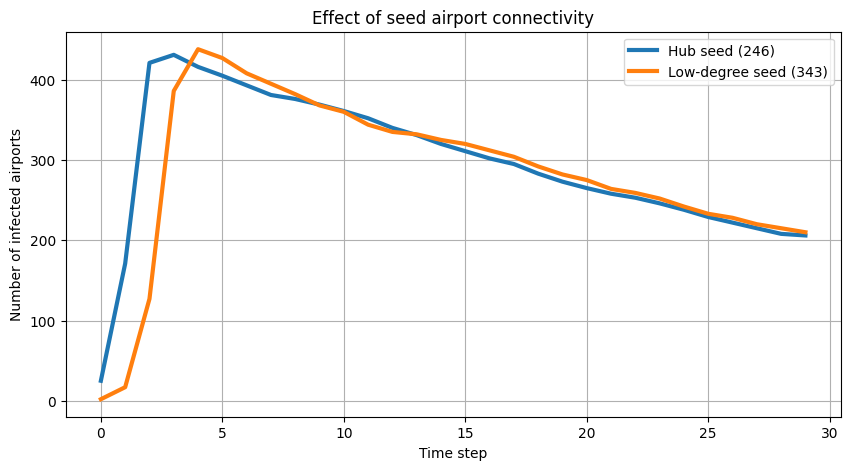

In [66]:
plt.figure(figsize=(10,5))

plt.plot(
    sir_hub["t"],
    sir_hub["I"],
    linewidth=3,
    label=f"Hub seed ({hub_airport})"
)

plt.plot(
    sir_low["t"],
    sir_low["I"],
    linewidth=3,
    label=f"Low-degree seed ({low_degree_airport})"
)

plt.xlabel("Time step")
plt.ylabel("Number of infected airports")

plt.title("Effect of seed airport connectivity")

plt.grid(True)
plt.legend()

plt.show()

## Conclusions

The SIR simulations reveal that the spreading dynamics strongly depend on the topology of the airport network.

Highly connected hub airports generate significantly faster and larger propagation processes than low-degree airports. This highlights the dominant role of central nodes in transportation networks.

The geographic visualization also shows that long-range flight connections enable rapid coast-to-coast diffusion, demonstrating the small-world nature of the network.

Overall, the results indicate that the USA airport network is highly efficient for transportation, but also highly vulnerable to fast spreading processes originating at central hubs.